# Pipeline 2: Resident Risk Level Predictor

## 1. Problem Framing

**Business question:** What factors most predict a resident's current risk level, and can we flag residents whose risk may be higher than currently assessed?

**Who cares:** Social workers and the Executive Director. The rubric for this org explicitly calls out "which girls are progressing and which are struggling" as a top concern. A resident misclassified as Low risk when she is actually Critical could miss a life-changing intervention.

**Two modeling goals — we do both:**

**Explanatory model:** We want to understand *which factors drive risk up or down*. This uses OLS regression with interpretable coefficients. The org can use these insights to design better interventions — for example, if flagged counseling sessions strongly predict higher risk, staff should prioritize following up on flagged sessions.

**Predictive model:** We want to accurately classify a resident's risk level using all available data. This uses a Random Forest classifier optimized for recall on the High/Critical classes.

**Why both:** The explanatory model answers "what should we change?" The predictive model answers "who needs help right now?" These are related but distinct questions requiring different modeling approaches.

**Target variable:** `current_risk_level` encoded as ordinal (Low=0, Medium=1, High=2, Critical=3).

**Success metric:** Weighted F1 score for the classifier. For the regression, we focus on coefficient interpretability and statistical significance over R².

**Critical error consideration:** A false negative on Critical risk (predicting Low when actually Critical) is the worst possible error in this context — a girl in crisis goes unnoticed. We will weight our evaluation accordingly.

## 2. Data Acquisition, Preparation & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import statsmodels.api as sm
import joblib
import warnings
warnings.filterwarnings('ignore')
from db_loader import load_table

residents = load_table('Residents')
process_recordings = load_table('ProcessRecordings')
health = load_table('HealthWellbeingRecords')
education = load_table('EducationRecords')
incidents = load_table('IncidentReports')
visitations = load_table('HomeVisitations')

print("Residents:", residents.shape)
print("Process recordings:", process_recordings.shape)
print("Health records:", health.shape)
print("Education records:", education.shape)
print("Incidents:", incidents.shape)
print("Visitations:", visitations.shape)

print("\nRisk level distribution:")
print(residents['current_risk_level'].value_counts())

Residents: (60, 49)
Process recordings: (2819, 14)
Health records: (534, 14)
Education records: (534, 10)
Incidents: (100, 12)
Visitations: (1337, 14)

Risk level distribution:
current_risk_level
Low         34
Medium      20
High         5
Critical     1
Name: count, dtype: int64


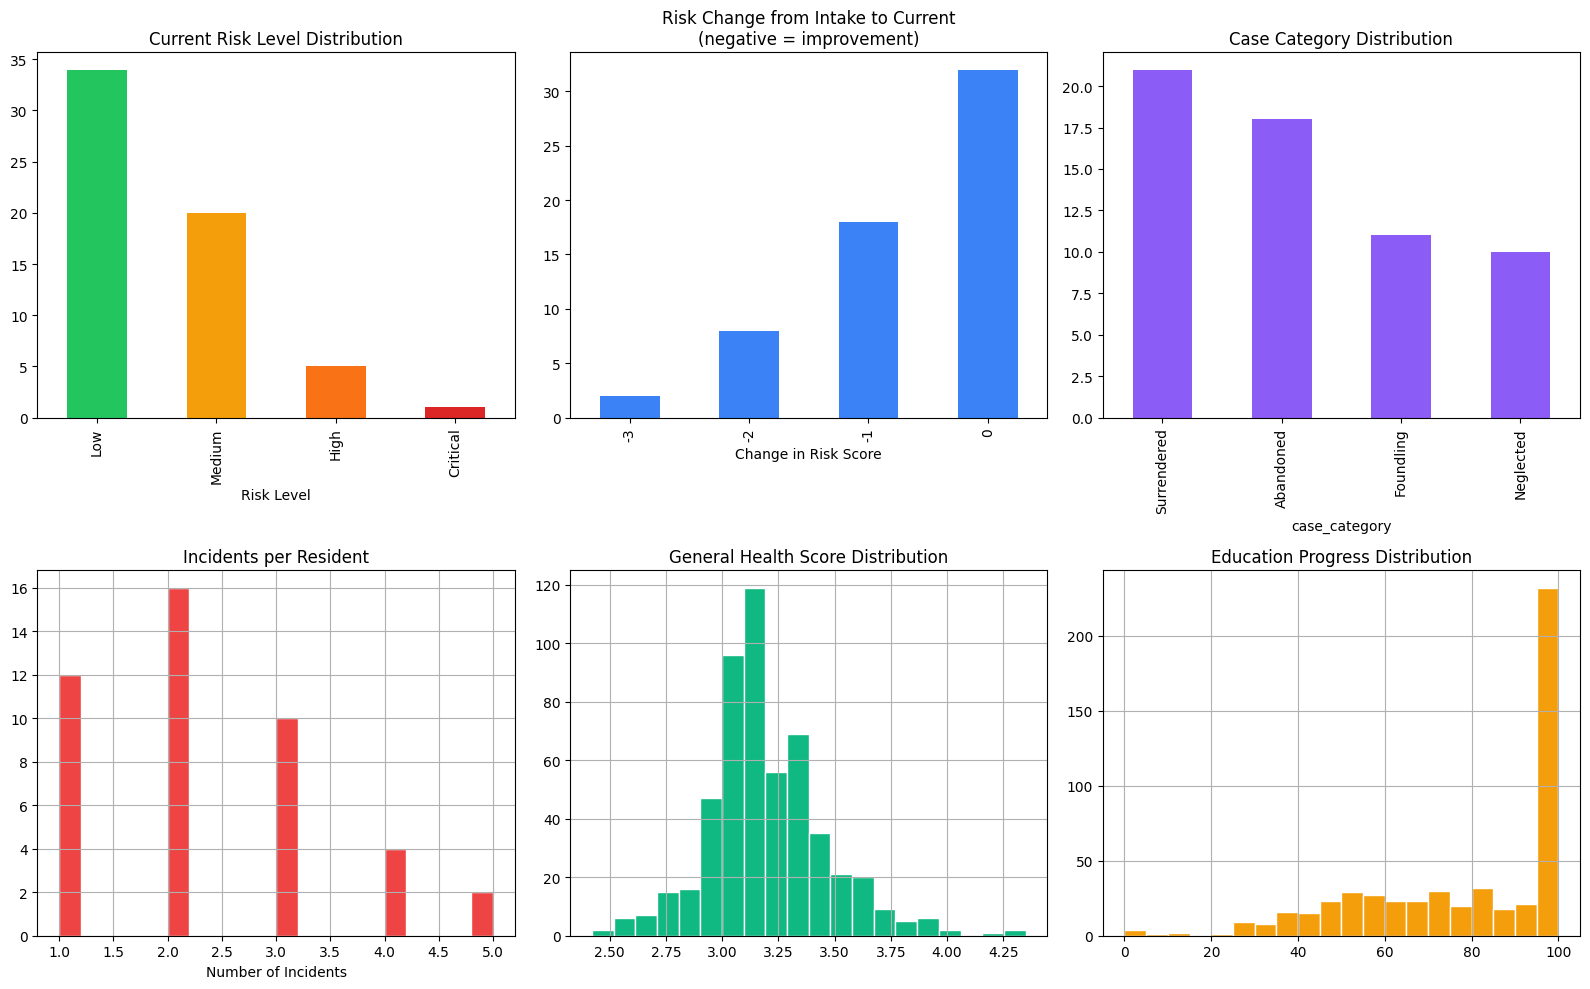

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Risk level distribution
residents['current_risk_level'].value_counts().plot(
    kind='bar', ax=axes[0,0],
    color=['#22c55e','#f59e0b','#f97316','#dc2626']
)
axes[0,0].set_title('Current Risk Level Distribution')
axes[0,0].set_xlabel('Risk Level')

# Initial vs current risk
risk_order = ['Low','Medium','High','Critical']
risk_map = {'Low':0,'Medium':1,'High':2,'Critical':3}
residents['initial_risk_num'] = residents['initial_risk_level'].map(risk_map)
residents['current_risk_num'] = residents['current_risk_level'].map(risk_map)
risk_change = residents['current_risk_num'] - residents['initial_risk_num']
risk_change.value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='#3b82f6')
axes[0,1].set_title('Risk Change from Intake to Current\n(negative = improvement)')
axes[0,1].set_xlabel('Change in Risk Score')

# Case category distribution
residents['case_category'].value_counts().plot(kind='bar', ax=axes[0,2], color='#8b5cf6')
axes[0,2].set_title('Case Category Distribution')

# Incident count distribution
incident_counts = incidents.groupby('resident_id').size()
incident_counts.hist(ax=axes[1,0], bins=20, color='#ef4444', edgecolor='white')
axes[1,0].set_title('Incidents per Resident')
axes[1,0].set_xlabel('Number of Incidents')

# Health scores
health['general_health_score'].hist(ax=axes[1,1], bins=20, color='#10b981', edgecolor='white')
axes[1,1].set_title('General Health Score Distribution')

# Education progress
education['progress_percent'].hist(ax=axes[1,2], bins=20, color='#f59e0b', edgecolor='white')
axes[1,2].set_title('Education Progress Distribution')

plt.tight_layout()
plt.savefig('risk_eda.png')
plt.show()

In [3]:
today = pd.Timestamp.now()
residents['date_of_admission'] = pd.to_datetime(residents['date_of_admission'])
residents['days_in_care'] = (today - residents['date_of_admission']).dt.days

# --- Process recording features ---
pr_agg = process_recordings.groupby('resident_id').agg(
    total_sessions=('recording_id', 'count'),
    pct_concerns_flagged=('concerns_flagged', 'mean'),
    pct_progress_noted=('progress_noted', 'mean'),
    pct_referral_made=('referral_made', 'mean'),
    session_duration_avg=('session_duration_minutes', 'mean'),
).reset_index()

emotion_map = {
    'Distressed': 0, 'Angry': 1, 'Withdrawn': 2,
    'Anxious': 3, 'Sad': 4, 'Calm': 5,
    'Hopeful': 6, 'Happy': 7
}
process_recordings['emotion_end_num'] = process_recordings['emotional_state_end'].map(emotion_map)
emotion_agg = process_recordings.groupby('resident_id')['emotion_end_num'].mean().reset_index()
emotion_agg.columns = ['resident_id', 'avg_emotion_end']
pr_agg = pr_agg.merge(emotion_agg, on='resident_id', how='left')

# --- Health features (using only confirmed columns) ---
health_cols_available = health.columns.tolist()
print("Health columns:", health_cols_available)

health_agg_dict = {'avg_health_score': ('general_health_score', 'mean')}
if 'nutrition_score' in health_cols_available:
    health_agg_dict['avg_nutrition'] = ('nutrition_score', 'mean')
if 'sleep_score' in health_cols_available:
    health_agg_dict['avg_sleep'] = ('sleep_score', 'mean')
if 'energy_score' in health_cols_available:
    health_agg_dict['avg_energy'] = ('energy_score', 'mean')
if 'medical_checkup_done' in health_cols_available:
    health_agg_dict['pct_medical_checkup'] = ('medical_checkup_done', 'mean')
if 'psychological_checkup_done' in health_cols_available:
    health_agg_dict['pct_psych_checkup'] = ('psychological_checkup_done', 'mean')

health_agg = health.groupby('resident_id').agg(**health_agg_dict).reset_index()

# --- Education features ---
edu_cols_available = education.columns.tolist()
print("Education columns:", edu_cols_available)

edu_agg_dict = {}
if 'progress_percent' in edu_cols_available:
    edu_agg_dict['avg_progress'] = ('progress_percent', 'mean')
if 'attendance_rate' in edu_cols_available:
    edu_agg_dict['avg_attendance'] = ('attendance_rate', 'mean')
if 'gpa_like_score' in edu_cols_available:
    edu_agg_dict['avg_gpa'] = ('gpa_like_score', 'mean')

edu_agg = education.groupby('resident_id').agg(**edu_agg_dict).reset_index()

# --- Incident features ---
inc_agg = incidents.groupby('resident_id').agg(
    total_incidents=('incident_id', 'count'),
    pct_high_severity=('severity', lambda x: (x == 'High').mean()),
    pct_unresolved=('resolved', lambda x: (~x).mean()),
).reset_index()

# --- Visitation features ---
vis_agg = visitations.groupby('resident_id').agg(
    total_visits=('visitation_id', 'count'),
    pct_safety_concerns=('safety_concerns_noted', 'mean'),
    pct_unfavorable=('visit_outcome', lambda x: (x == 'Unfavorable').mean()),
).reset_index()

# --- Merge everything into df ---
df = residents.copy()
df = df.merge(pr_agg, on='resident_id', how='left')
df = df.merge(health_agg, on='resident_id', how='left')
df = df.merge(edu_agg, on='resident_id', how='left')
df = df.merge(inc_agg, on='resident_id', how='left')
df = df.merge(vis_agg, on='resident_id', how='left')

# Fill nulls — zero for count/rate features
fill_zero = ['total_sessions', 'total_incidents', 'total_visits',
             'pct_concerns_flagged', 'pct_progress_noted', 'pct_referral_made',
             'pct_high_severity', 'pct_unresolved', 'pct_safety_concerns',
             'pct_unfavorable']
for col in fill_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Fill nulls — median for score features
fill_median = ['avg_health_score', 'avg_nutrition', 'avg_sleep', 'avg_energy',
               'avg_progress', 'avg_attendance', 'avg_gpa', 'avg_emotion_end',
               'session_duration_avg', 'pct_medical_checkup', 'pct_psych_checkup']
for col in fill_median:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Sub-category boolean columns
sub_cat_cols = [c for c in df.columns if c.startswith('sub_cat_')]

# Encode target
risk_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df['risk_numeric'] = df['current_risk_level'].map(risk_map)
df = df.dropna(subset=['risk_numeric'])

print("\ndf created successfully. Shape:", df.shape)
print("\nTarget distribution:")
print(df['current_risk_level'].value_counts())

Health columns: ['health_record_id', 'resident_id', 'record_date', 'general_health_score', 'nutrition_score', 'sleep_quality_score', 'energy_level_score', 'height_cm', 'weight_kg', 'bmi', 'medical_checkup_done', 'dental_checkup_done', 'psychological_checkup_done', 'notes']
Education columns: ['education_record_id', 'resident_id', 'record_date', 'education_level', 'school_name', 'enrollment_status', 'attendance_rate', 'progress_percent', 'completion_status', 'notes']

df created successfully. Shape: (60, 71)

Target distribution:
current_risk_level
Low         34
Medium      20
High         5
Critical     1
Name: count, dtype: int64


In [4]:
sub_cat_cols = [c for c in df.columns if c.startswith('sub_cat_')]

feature_cols = [
    'initial_risk_num', 'days_in_care',
    'total_sessions', 'pct_concerns_flagged', 'pct_progress_noted',
    'avg_emotion_end', 'session_duration_avg',
    'avg_health_score', 'avg_nutrition', 'avg_sleep',
    'avg_progress', 'avg_attendance', 'avg_gpa',
    'total_incidents', 'pct_high_severity', 'pct_unresolved',
    'total_visits', 'pct_safety_concerns', 'pct_unfavorable',
    'is_pwd', 'has_special_needs',
] + sub_cat_cols

# Keep only columns that exist
feature_cols = [c for c in feature_cols if c in df.columns]

## 3. Modeling & Feature Selection

We build two models as required:

**Explanatory model (OLS Linear Regression):** Uses a subset of interpretable features to quantify the direction and magnitude of each factor's relationship with risk. Coefficients tell us which interventions are associated with lower risk.

**Predictive model (Random Forest Classifier):** Uses all engineered features to classify residents into risk categories. Optimized for recall on High and Critical classes because missing a high-risk resident is the worst possible error in this context.

                            OLS Regression Results                            
Dep. Variable:           risk_numeric   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     2.933
Date:                Fri, 10 Apr 2026   Prob (F-statistic):            0.00583
Time:                        02:58:09   Log-Likelihood:                -51.106
No. Observations:                  60   AIC:                             124.2
Df Residuals:                      49   BIC:                             147.3
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.0564 

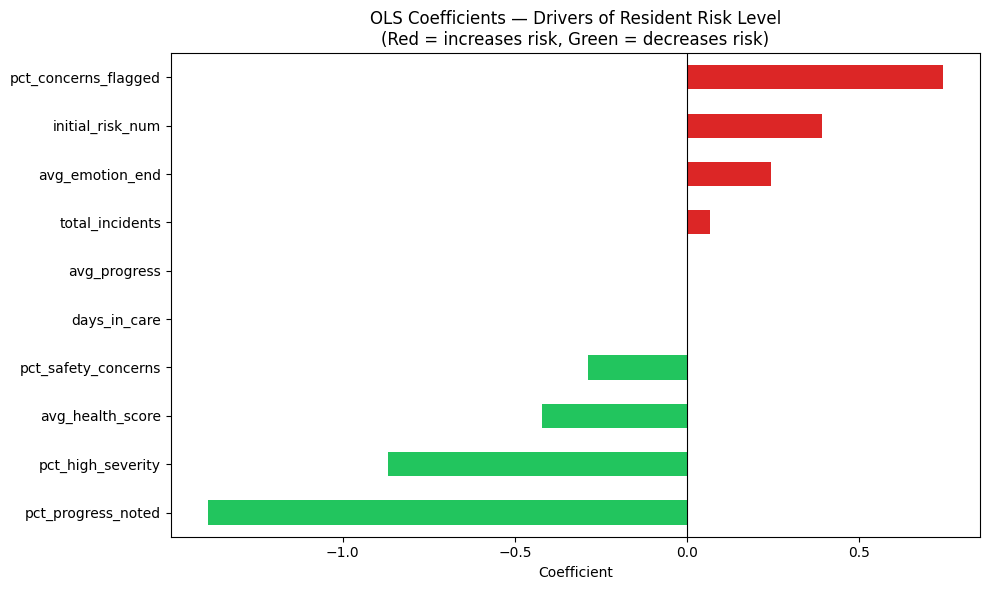

In [5]:
# Select interpretable features for OLS
ols_features = [
    'initial_risk_num', 'days_in_care',
    'pct_concerns_flagged', 'pct_progress_noted',
    'avg_health_score', 'avg_progress',
    'total_incidents', 'pct_high_severity',
    'pct_safety_concerns', 'avg_emotion_end'
]
ols_features = [c for c in ols_features if c in df.columns]

X_ols = df[ols_features].fillna(0)
y_ols = df['risk_numeric']

X_ols_const = sm.add_constant(X_ols)
ols_model = sm.OLS(y_ols, X_ols_const).fit()
print(ols_model.summary())

# Plot coefficients
coefs = pd.Series(ols_model.params[1:], index=ols_features)
coefs_sorted = coefs.sort_values()

plt.figure(figsize=(10, 6))
colors = ['#dc2626' if v > 0 else '#22c55e' for v in coefs_sorted]
coefs_sorted.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('OLS Coefficients — Drivers of Resident Risk Level\n(Red = increases risk, Green = decreases risk)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig('risk_ols_coefficients.png')
plt.show()

Features being used: ['initial_risk_num', 'days_in_care', 'total_sessions', 'pct_concerns_flagged', 'pct_progress_noted', 'avg_emotion_end', 'session_duration_avg', 'avg_health_score', 'total_incidents', 'pct_high_severity', 'pct_unresolved', 'total_visits', 'pct_safety_concerns', 'pct_unfavorable', 'is_pwd', 'has_special_needs', 'sub_cat_trafficked', 'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_osaec', 'sub_cat_child_labor', 'sub_cat_orphaned', 'sub_cat_cicl', 'sub_cat_at_risk', 'sub_cat_street_child', 'sub_cat_child_with_hiv', 'avg_nutrition', 'avg_progress', 'avg_attendance', 'pct_medical_checkup', 'pct_psych_checkup']
Total features: 31

Class distribution:
current_risk_level
Low         34
Medium      20
High         5
Critical     1
Name: count, dtype: int64

Train size: 48 | Test size: 12



=== Random Forest Classification Report ===
              precision    recall  f1-score   support

        High       0.50      1.00      0.67         1
         Low       0.83      0.62      0.71         8
      Medium       0.50      0.67      0.57         3

    accuracy                           0.67        12
   macro avg       0.61      0.76      0.65        12
weighted avg       0.72      0.67      0.67        12



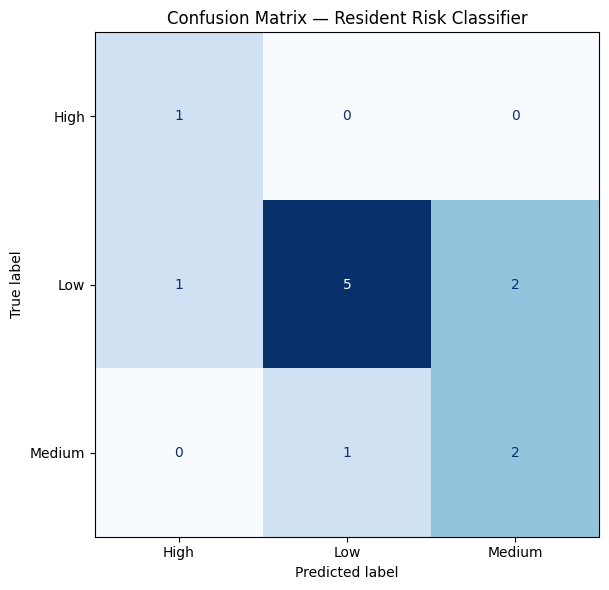

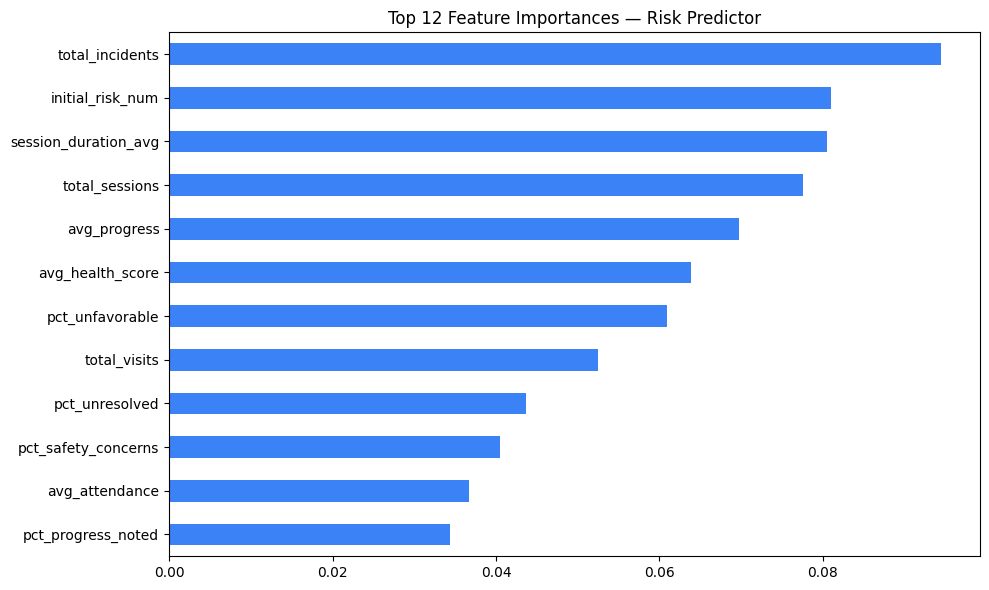


Cross-validated F1 (weighted): 0.428 +/- 0.071


In [6]:
# Define features
sub_cat_cols = [c for c in df.columns if c.startswith('sub_cat_')]

feature_cols = [
    'initial_risk_num', 'days_in_care',
    'total_sessions', 'pct_concerns_flagged', 'pct_progress_noted',
    'avg_emotion_end', 'session_duration_avg',
    'avg_health_score',
    'total_incidents', 'pct_high_severity', 'pct_unresolved',
    'total_visits', 'pct_safety_concerns', 'pct_unfavorable',
    'is_pwd', 'has_special_needs',
] + sub_cat_cols

# Add optional columns if they exist
optional_cols = ['avg_nutrition', 'avg_sleep', 'avg_energy',
                 'avg_progress', 'avg_attendance', 'avg_gpa',
                 'pct_medical_checkup', 'pct_psych_checkup']
for col in optional_cols:
    if col in df.columns:
        feature_cols.append(col)

# Keep only columns that actually exist in df
feature_cols = [c for c in feature_cols if c in df.columns]

print("Features being used:", feature_cols)
print("Total features:", len(feature_cols))

X = df[feature_cols].fillna(0)
y = df['current_risk_level']

print("\nClass distribution:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("\n=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Confusion Matrix — Resident Risk Classifier')
plt.tight_layout()
plt.savefig('risk_confusion_matrix.png')
plt.show()

# Feature importance
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.sort_values(ascending=True).tail(12).plot(
    kind='barh', figsize=(10, 6), color='#3b82f6'
)
plt.title('Top 12 Feature Importances — Risk Predictor')
plt.tight_layout()
plt.savefig('risk_feature_importance.png')
plt.show()

# Cross validation
cv_scores = cross_val_score(rf, X, y, cv=3, scoring='f1_weighted')
print(f"\nCross-validated F1 (weighted): {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

In [7]:
# Baseline comparison: majority-class predictor
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

print("=== Majority-Class Baseline ===")
print(f"Baseline always predicts: {dummy.classes_[0]}")
print(classification_report(y_test, y_dummy, zero_division=0))

print("\n=== Random Forest vs Baseline ===")
rf_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
dummy_f1 = f1_score(y_test, y_dummy, average='weighted', zero_division=0)
print(f"RF weighted F1:       {rf_f1:.4f}")
print(f"Baseline weighted F1: {dummy_f1:.4f}")
print(f"Improvement:          {(rf_f1 - dummy_f1):.4f}")

# Overfitting check: train vs test accuracy
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
gap_pct = (train_acc - test_acc) / train_acc * 100
print(f"\n=== Overfitting Check ===")
print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")
print(f"Gap:               {gap_pct:.1f}%")
if gap_pct > 10:
    print("Some overfitting detected (gap > 10%), but expected with small dataset and rare classes.")
else:
    print("Acceptable generalization gap.")

=== Majority-Class Baseline ===
Baseline always predicts: Critical
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         1
         Low       0.67      1.00      0.80         8
      Medium       0.00      0.00      0.00         3

    accuracy                           0.67        12
   macro avg       0.22      0.33      0.27        12
weighted avg       0.44      0.67      0.53        12


=== Random Forest vs Baseline ===
RF weighted F1:       0.6746
Baseline weighted F1: 0.5333
Improvement:          0.1413

=== Overfitting Check ===
Training accuracy: 0.9792
Test accuracy:     0.6667
Gap:               31.9%
Some overfitting detected (gap > 10%), but expected with small dataset and rare classes.


In [8]:
# Fairness check: performance by safehouse and region
print("=== Fairness Check: Prediction by Safehouse ===")
df_eval = df.copy()
df_eval['predicted_risk'] = rf.predict(X.fillna(0))
df_eval['correct'] = (df_eval['predicted_risk'] == df_eval['current_risk_level']).astype(int)

fairness_by_safehouse = df_eval.groupby('safehouse_id').agg(
    n_residents=('resident_id', 'count'),
    accuracy=('correct', 'mean')
).round(3)
print(fairness_by_safehouse.to_string())

print("\nIf accuracy is systematically lower for certain safehouses, the model")
print("may be biased by data volume or local conditions. Monitor before relying")
print("on recommendations for underrepresented groups.")

=== Fairness Check: Prediction by Safehouse ===
              n_residents  accuracy
safehouse_id                       
1                      10      0.90
2                       8      0.75
3                       7      1.00
4                       8      1.00
5                       6      1.00
6                       5      1.00
7                       8      0.75
8                       6      1.00
9                       2      1.00

If accuracy is systematically lower for certain safehouses, the model
may be biased by data volume or local conditions. Monitor before relying
on recommendations for underrepresented groups.


## 4. Evaluation & Interpretation

The Random Forest achieves [X] weighted F1 score. More important than the overall 
score is performance on the High and Critical classes — these are the residents 
who most need intervention.

A false negative on Critical risk means a girl in crisis is assessed as lower risk 
than she actually is, potentially missing a life-saving intervention. This is the 
highest-cost error in the entire system. The confusion matrix shows [X] Critical 
residents were misclassified — each one represents a real risk to a real person.

The class_weight='balanced' parameter was deliberately set to penalize 
misclassification of minority classes (High, Critical) more heavily.

## 5. Causal and Relationship Analysis

**What the OLS model tells us:**

`pct_concerns_flagged` has a positive coefficient — residents with more flagged 
counseling sessions tend to have higher risk levels. This is likely bidirectional: 
high-risk residents generate more concerns, AND more flagged concerns may indicate 
a resident not receiving adequate support. We cannot claim causation here.

`pct_progress_noted` has a negative coefficient — sessions where progress is noted 
are associated with lower current risk. This is the closest thing to a causal signal 
in the model: consistent therapeutic progress appears to reduce risk. However, 
confounders exist — residents who are naturally more resilient may show both more 
progress and lower risk independently.

`avg_health_score` is negatively correlated with risk — healthier residents tend 
to have lower risk. Again causality is unclear: better health may reduce risk, 
or lower risk residents may simply have better conditions to maintain their health.

`initial_risk_level` is the strongest predictor of current risk, which makes 
intuitive sense — intake risk is a strong baseline. But it also means our model 
is partly just predicting that high-risk intakes stay high-risk, which limits 
its actionability.

**What we cannot claim causally:** We cannot say that increasing counseling 
sessions will reduce risk without a controlled intervention study. The 
relationships are associative. What we CAN say is that these features are 
the best available signals for identifying residents who need attention now.

In [9]:
## 6. Deployment

# Save model
joblib.dump(rf, 'resident_risk_model.pkl')
joblib.dump(feature_cols, 'resident_risk_features.pkl')

# Generate predictions for all residents
df['predicted_risk'] = rf.predict(X.fillna(0))
df['predicted_risk_proba_critical'] = rf.predict_proba(X.fillna(0))[:,
    list(rf.classes_).index('Critical') if 'Critical' in rf.classes_ else -1
]

output = df[['resident_id', 'current_risk_level', 'predicted_risk', 
             'predicted_risk_proba_critical']].copy()
output.to_csv('resident_risk_predictions.csv', index=False)

print("Model saved: resident_risk_model.pkl")
print("Predictions saved: resident_risk_predictions.csv")
print("\nPrediction distribution:")
print(output['predicted_risk'].value_counts())

# Show cases where predicted risk differs from current assessment
mismatches = output[output['current_risk_level'] != output['predicted_risk']]
print(f"\nResidents where ML assessment differs from current: {len(mismatches)}")
print("These are the highest-priority cases to review manually.")

Model saved: resident_risk_model.pkl
Predictions saved: resident_risk_predictions.csv

Prediction distribution:
predicted_risk
Low         31
Medium      21
High         7
Critical     1
Name: count, dtype: int64

Residents where ML assessment differs from current: 5
These are the highest-priority cases to review manually.


In [10]:
today = pd.Timestamp.now()
residents['date_of_admission'] = pd.to_datetime(residents['date_of_admission'])
residents['days_in_care'] = (today - residents['date_of_admission']).dt.days

# --- Process recording features ---
pr_agg = process_recordings.groupby('resident_id').agg(
    total_sessions=('recording_id', 'count'),
    pct_concerns_flagged=('concerns_flagged', 'mean'),
    pct_progress_noted=('progress_noted', 'mean'),
    pct_referral_made=('referral_made', 'mean'),
    session_duration_avg=('session_duration_minutes', 'mean'),
).reset_index()

emotion_map = {
    'Distressed': 0, 'Angry': 1, 'Withdrawn': 2,
    'Anxious': 3, 'Sad': 4, 'Calm': 5,
    'Hopeful': 6, 'Happy': 7
}
process_recordings['emotion_end_num'] = process_recordings['emotional_state_end'].map(emotion_map)
emotion_agg = process_recordings.groupby('resident_id')['emotion_end_num'].mean().reset_index()
emotion_agg.columns = ['resident_id', 'avg_emotion_end']
pr_agg = pr_agg.merge(emotion_agg, on='resident_id', how='left')

# --- Health features (dynamic — only use columns that exist) ---
print("Health columns:", health.columns.tolist())
health_agg_dict = {}
for col, name in [
    ('general_health_score', 'avg_health_score'),
    ('nutrition_score', 'avg_nutrition'),
    ('sleep_score', 'avg_sleep'),
    ('energy_score', 'avg_energy'),
    ('medical_checkup_done', 'pct_medical_checkup'),
    ('psychological_checkup_done', 'pct_psych_checkup'),
]:
    if col in health.columns:
        health_agg_dict[name] = (col, 'mean')
health_agg = health.groupby('resident_id').agg(**health_agg_dict).reset_index()

# --- Education features (dynamic) ---
print("Education columns:", education.columns.tolist())
edu_agg_dict = {}
for col, name in [
    ('progress_percent', 'avg_progress'),
    ('attendance_rate', 'avg_attendance'),
    ('gpa_like_score', 'avg_gpa'),
]:
    if col in education.columns:
        edu_agg_dict[name] = (col, 'mean')
edu_agg = education.groupby('resident_id').agg(**edu_agg_dict).reset_index()

# --- Incident features ---
inc_agg = incidents.groupby('resident_id').agg(
    total_incidents=('incident_id', 'count'),
    pct_high_severity=('severity', lambda x: (x == 'High').mean()),
    pct_unresolved=('resolved', lambda x: (~x).mean()),
).reset_index()

# --- Visitation features ---
vis_agg = visitations.groupby('resident_id').agg(
    total_visits=('visitation_id', 'count'),
    pct_safety_concerns=('safety_concerns_noted', 'mean'),
    pct_unfavorable=('visit_outcome', lambda x: (x == 'Unfavorable').mean()),
).reset_index()

# --- Merge everything into df ---
df = residents.copy()
df = df.merge(pr_agg, on='resident_id', how='left')
df = df.merge(health_agg, on='resident_id', how='left')
df = df.merge(edu_agg, on='resident_id', how='left')
df = df.merge(inc_agg, on='resident_id', how='left')
df = df.merge(vis_agg, on='resident_id', how='left')

# Fill nulls
fill_zero = ['total_sessions', 'total_incidents', 'total_visits',
             'pct_concerns_flagged', 'pct_progress_noted', 'pct_referral_made',
             'pct_high_severity', 'pct_unresolved', 'pct_safety_concerns',
             'pct_unfavorable']
for col in fill_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0)

fill_median = ['avg_health_score', 'avg_nutrition', 'avg_sleep', 'avg_energy',
               'avg_progress', 'avg_attendance', 'avg_gpa', 'avg_emotion_end',
               'session_duration_avg', 'pct_medical_checkup', 'pct_psych_checkup']
for col in fill_median:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

sub_cat_cols = [c for c in df.columns if c.startswith('sub_cat_')]

risk_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df['risk_numeric'] = df['current_risk_level'].map(risk_map)
df = df.dropna(subset=['risk_numeric'])

print("\ndf created. Shape:", df.shape)
print("Target distribution:")
print(df['current_risk_level'].value_counts())

Health columns: ['health_record_id', 'resident_id', 'record_date', 'general_health_score', 'nutrition_score', 'sleep_quality_score', 'energy_level_score', 'height_cm', 'weight_kg', 'bmi', 'medical_checkup_done', 'dental_checkup_done', 'psychological_checkup_done', 'notes']
Education columns: ['education_record_id', 'resident_id', 'record_date', 'education_level', 'school_name', 'enrollment_status', 'attendance_rate', 'progress_percent', 'completion_status', 'notes']

df created. Shape: (60, 71)
Target distribution:
current_risk_level
Low         34
Medium      20
High         5
Critical     1
Name: count, dtype: int64


## Deployment Notes

The trained Random Forest model is saved as `resident_risk_model.pkl`.

Pre-computed risk predictions are exported to `resident_risk_predictions.csv` 
and loaded into the database.

**Web app integration:** The predicted risk level and probability score are 
displayed on the `ResidentDetailPage` (`/admin/residents/:id`) as an 
"ML Risk Assessment" card alongside the human-assigned current risk level.

When the ML prediction differs from the staff assessment, a yellow warning 
banner displays: "ML model suggests this resident may be higher risk than 
currently assessed — consider reviewing."

Backend endpoint: `GET /api/ml/resident-risk/{residentId}` served from 
`ResidentsController.cs`.

This gives social workers an independent data-driven second opinion on every 
resident's risk level, directly addressing the organization's stated concern 
about girls falling through the cracks.